# IP 03 — Integrated Output Visualization

Visualize the unified output using heatmaps and 24-hour demand lines with Peak-Risk markers.

In [1]:
# Import libraries
from pathlib import Path
import sys
import json
import yaml
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while (
    not (PROJECT_ROOT / "src").exists()
    and PROJECT_ROOT != PROJECT_ROOT.parent
):
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = (PROJECT_ROOT / "configs" / "integrated_pipeline.yaml")

with CONFIG_PATH.open("r", encoding="utf-8") as handle:
    CONFIG = yaml.safe_load(handle)

CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/integrated_pipeline.yaml')

In [3]:
# Import module for running Integrated Pipeline
from src.ontario_peak_risk.inference.plotting import (
    demand_heatmap,
    peak_risk_heatmap,
    peak_alert_heatmap,
    demand_lines_with_peak_alerts,
    peak_risk_lines,
    max_demand_by_fsa,
    alert_count_by_fsa,
)

In [4]:
# Config values 
OUTPUT_DIR = (
    PROJECT_ROOT
    / CONFIG["paths"]["outputs_dir"]
    / "historical_replay_demo"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / CONFIG["paths"]["figures_dir"]
    / "historical_replay_demo"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Recovery data
output = pd.read_parquet(
    OUTPUT_DIR
    / "integrated_24h_prediction.parquet"
)

display(output.head())

,fsa,forecast_origin,target_timestamp,horizon,forecast_consumption_kwh,peak_risk_score,peak_alert
0,L4T,2025-12-30 23:00:00,2025-12-31 00:00:00,1,11391.804060,0.000132,False
1,L4T,2025-12-30 23:00:00,2025-12-31 01:00:00,2,10575.189247,0.000073,False
2,L4T,2025-12-30 23:00:00,2025-12-31 02:00:00,3,9967.082221,0.000057,False
3,L4T,2025-12-30 23:00:00,2025-12-31 03:00:00,4,9662.285006,0.000113,False
4,L4T,2025-12-30 23:00:00,2025-12-31 04:00:00,5,9579.000471,0.000128,False


In [ ]:
# After `output` has been generated:
# demand_heatmap(output); plt.show()
# peak_risk_heatmap(output); plt.show()
# demand_lines_with_peak_alerts(output); plt.show()


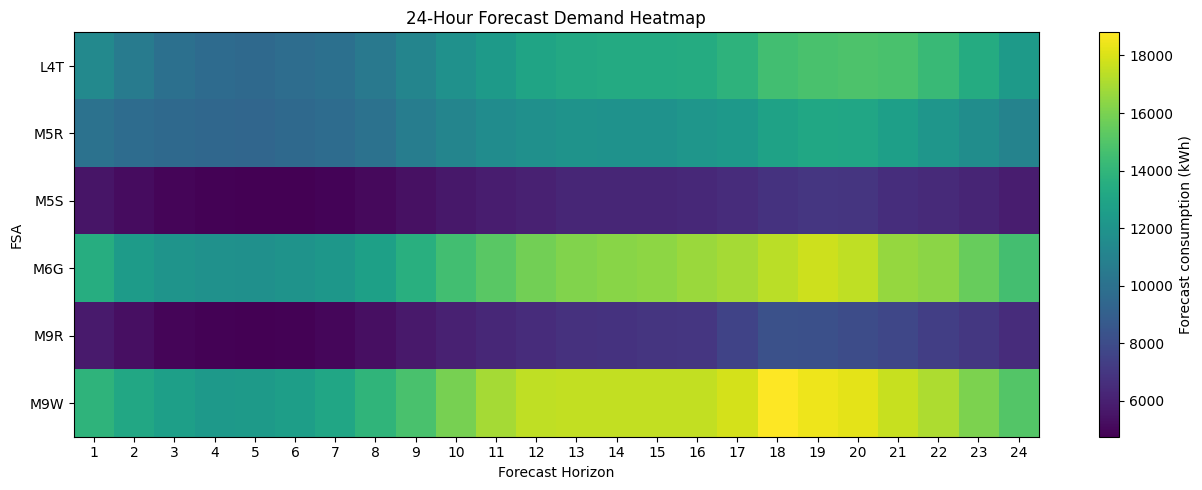

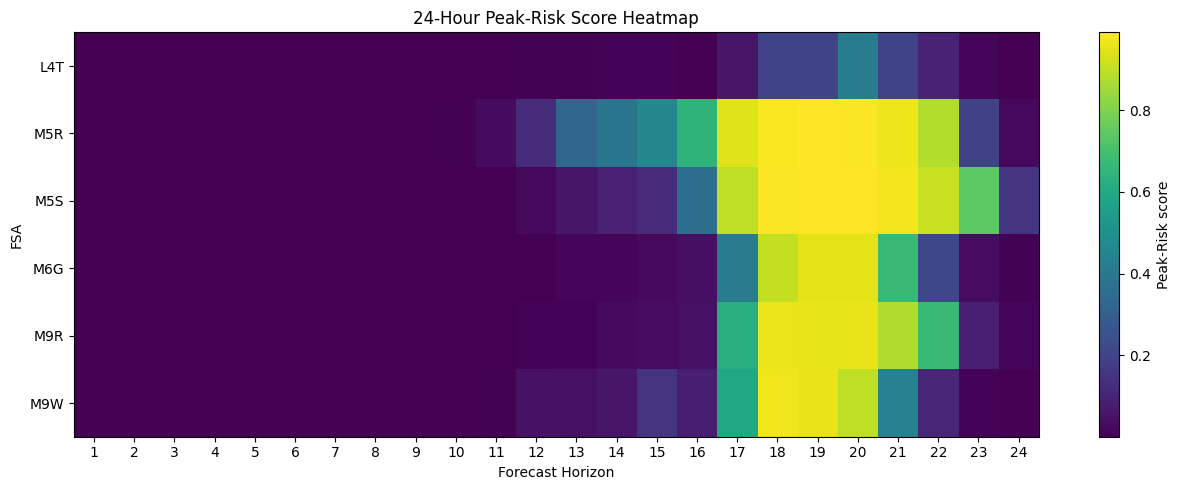

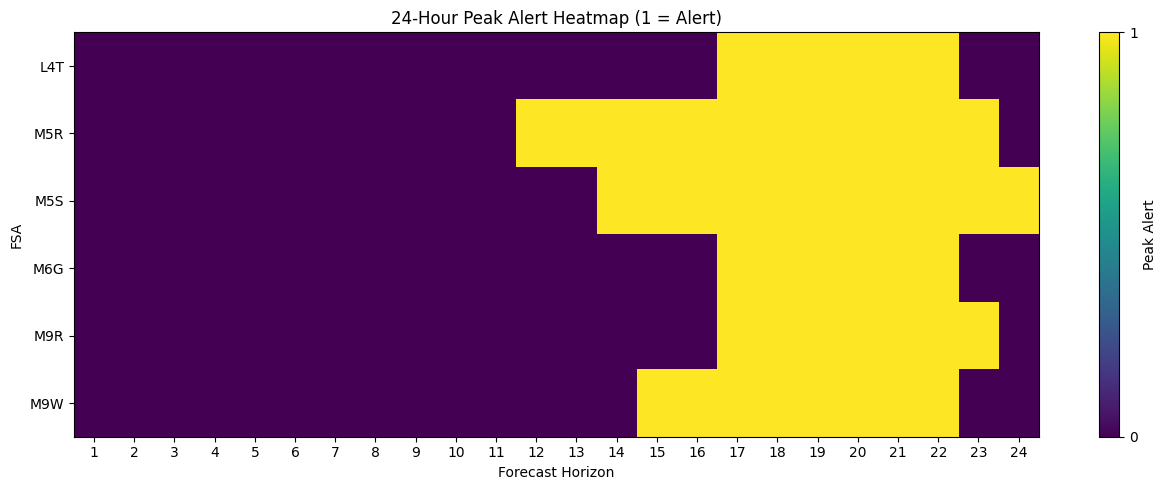

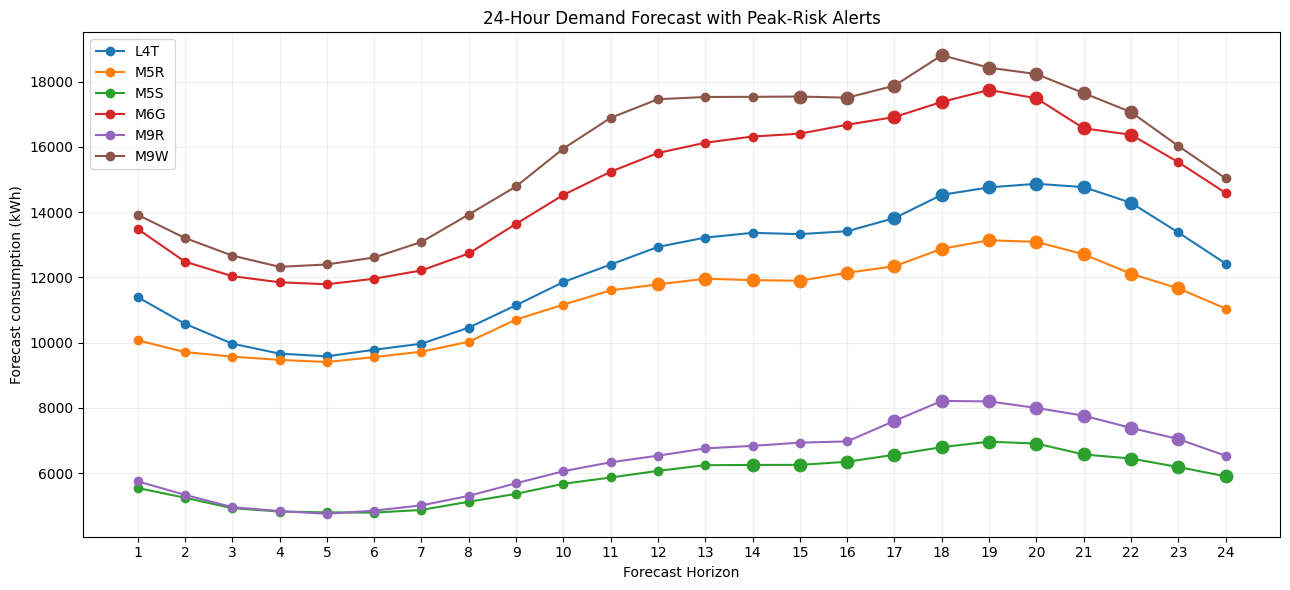

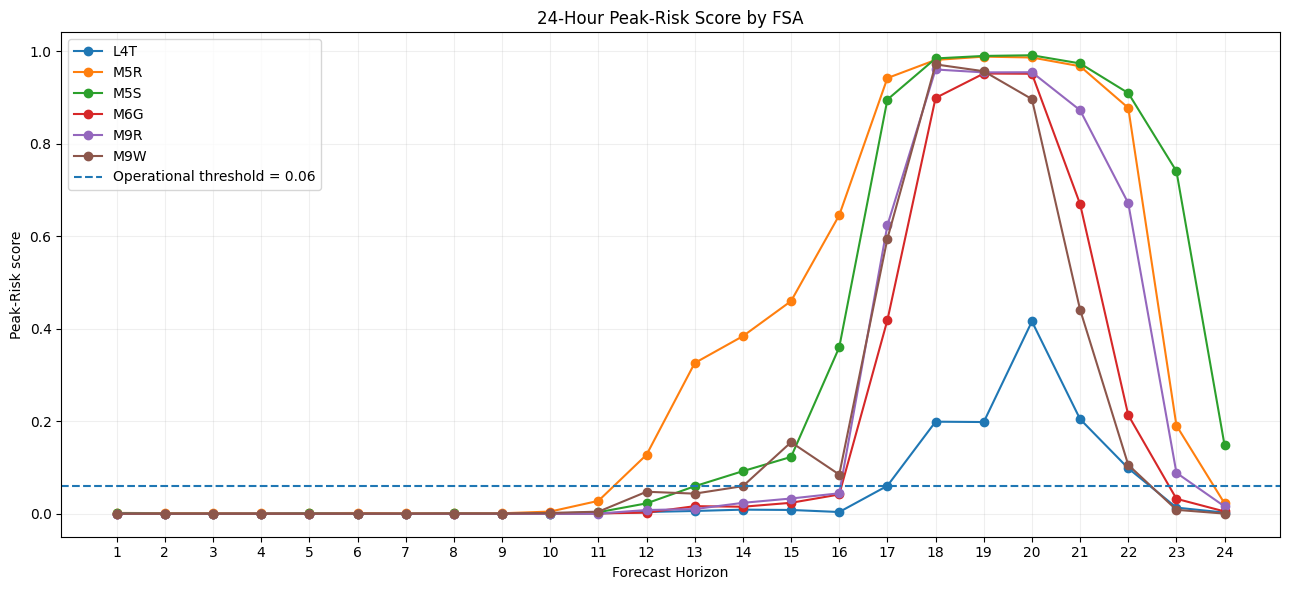

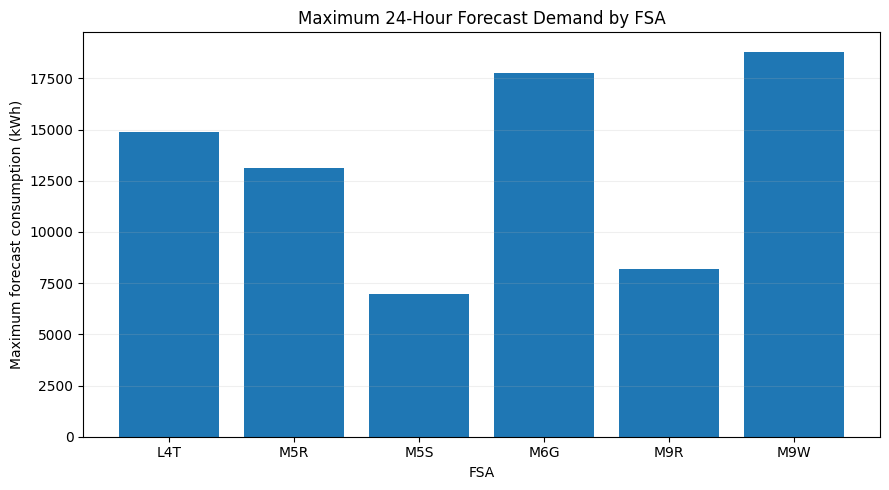

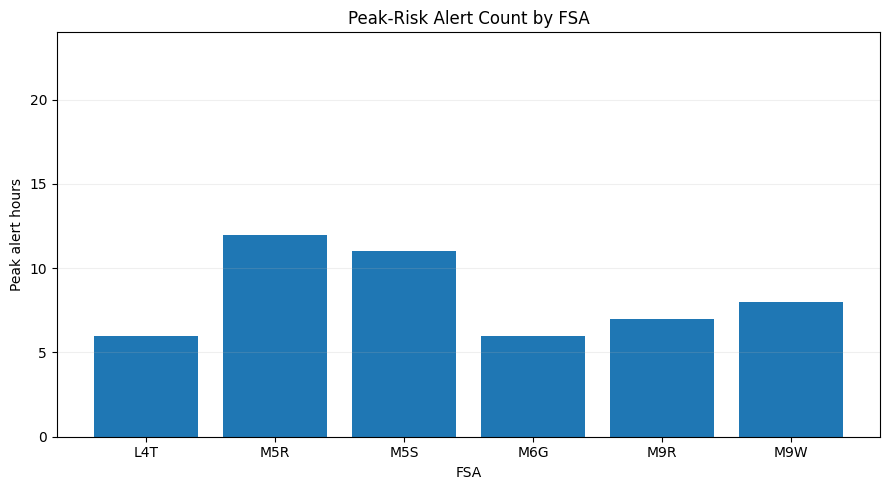

Figures saved to: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\reports\figures\integrated_pipeline\historical_replay_demo


In [5]:
# Generate figures
figures = {
    "IP_03_demand_heatmap.png":
        demand_heatmap(output),

    "IP_03_peak_risk_heatmap.png":
        peak_risk_heatmap(output),

    "IP_03_peak_alert_heatmap.png":
        peak_alert_heatmap(output),

    "IP_03_demand_lines_peak_alerts.png":
        demand_lines_with_peak_alerts(output),

    "IP_03_peak_risk_lines.png":
        peak_risk_lines(
            output,
            operational_threshold=float(
                CONFIG["prediction"][
                    "peak_operational_threshold"
                ]
            ),
        ),

    "IP_03_max_demand_by_fsa.png":
        max_demand_by_fsa(output),

    "IP_03_alert_count_by_fsa.png":
        alert_count_by_fsa(output),
}

for filename, fig in figures.items():
    fig.savefig(
        FIGURES_DIR / filename,
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()

print("Figures saved to:", FIGURES_DIR)

In [6]:

# Executive-style output table

executive_summary = (
    output
    .groupby("fsa", observed=True)
    .agg(
        max_forecast_consumption_kwh=(
            "forecast_consumption_kwh",
            "max",
        ),
        max_peak_risk_score=(
            "peak_risk_score",
            "max",
        ),
        peak_alert_hours=(
            "peak_alert",
            "sum",
        ),
    )
    .reset_index()
)

# Hour of maximum demand by FSA
idx = (
    output
    .groupby("fsa", observed=True)[
        "forecast_consumption_kwh"
    ]
    .idxmax()
)

max_hours = (
    output.loc[
        idx,
        [
            "fsa",
            "target_timestamp",
            "horizon",
        ],
    ]
    .rename(
        columns={
            "target_timestamp":
                "max_demand_timestamp",
            "horizon":
                "max_demand_horizon",
        }
    )
)

executive_summary = executive_summary.merge(
    max_hours,
    on="fsa",
    how="left",
)

display(executive_summary)

executive_summary.to_csv(
    OUTPUT_DIR
    / "integrated_24h_executive_summary.csv",
    index=False,
)


,fsa,max_forecast_consumption_kwh,max_peak_risk_score,peak_alert_hours,max_demand_timestamp,max_demand_horizon
0,L4T,14865.533818,0.415957,6,2025-12-31 19:00:00,20
1,M5R,13135.196049,0.988430,12,2025-12-31 18:00:00,19
2,M5S,6963.333033,0.991410,11,2025-12-31 18:00:00,19
3,M6G,17741.693093,0.951889,6,2025-12-31 18:00:00,19
4,M9R,8212.401477,0.960627,7,2025-12-31 17:00:00,18
5,M9W,18804.563871,0.971639,8,2025-12-31 17:00:00,18
